# Standard Neuron in Deep Learning

A comprehensive notebook covering:

- First-principles explanation
- Mathematical derivation
- NumPy implementation
- PyTorch implementation
- Training example
- Visualization
- Advantages & disadvantages
- Research papers
- Exercises


# 1. First-Principles Explanation

A biological neuron receives signals through dendrites, processes them in the cell body,
and produces an output through the axon.

An artificial neuron abstracts this process:

**Inputs → Weighted Sum → Activation Function → Output**

The weighted sum determines how important each input is, while the activation introduces
non-linearity so networks can learn complex functions.


# 2. Mathematical Derivation

Given inputs

\[
x=[x_1,x_2,\ldots,x_n]
\]

weights

\[
w=[w_1,w_2,\ldots,w_n]
\]

bias

\[
b
\]

Linear combination:

\[
z=\sum_i w_i x_i+b
\]

Activation:

\[
y=f(z)
\]

Common activations include Sigmoid, Tanh, and ReLU.


In [1]:
import numpy as np

x=np.array([2.,3.,1.])
w=np.array([0.5,-0.2,0.8])
b=0.1

z=np.dot(w,x)+b
print("z =",z)


z = 1.3


## Sigmoid

In [2]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

print(sigmoid(z))


0.7858349830425586


## ReLU

In [3]:
def relu(x):
    return np.maximum(0,x)

print(relu(z))


1.3


# 3. PyTorch Implementation

In [ ]:
import torch
import torch.nn as nn

class StandardNeuron(nn.Module):
    def __init__(self,in_features,activation='relu'):
        super().__init__()
        self.linear=nn.Linear(in_features,1)

        if activation=='relu':
            self.activation=nn.ReLU()
        elif activation=='sigmoid':
            self.activation=nn.Sigmoid()
        elif activation=='tanh':
            self.activation=nn.Tanh()
        else:
            self.activation=nn.Identity()

    def forward(self,x):
        return self.activation(self.linear(x))

model=StandardNeuron(2)
print(model)


# 4. Example Usage

In [ ]:
x=torch.tensor([[0.,0.],
                        [0.,1.],
                        [1.,0.],
                        [1.,1.]])
print(model(x))


# 5. Training on XOR (illustrates limitation of single neuron)

In [ ]:
import torch.optim as optim

x=torch.tensor([[0.,0.],
                [0.,1.],
                [1.,0.],
                [1.,1.]])
y=torch.tensor([[0.],[1.],[1.],[0.]])

model=StandardNeuron(2,activation='sigmoid')

criterion=nn.BCELoss()
optimizer=optim.SGD(model.parameters(),lr=0.1)

for epoch in range(200):
    optimizer.zero_grad()
    pred=model(x)
    loss=criterion(pred,y)
    loss.backward()
    optimizer.step()

print("Final loss:",loss.item())
print(model(x).detach())
print("Notice that a single neuron cannot solve XOR perfectly.")


# 6. Visualization

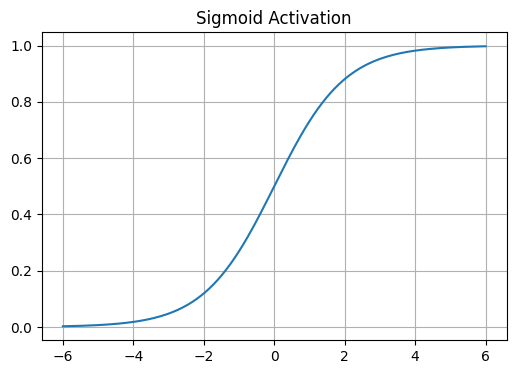

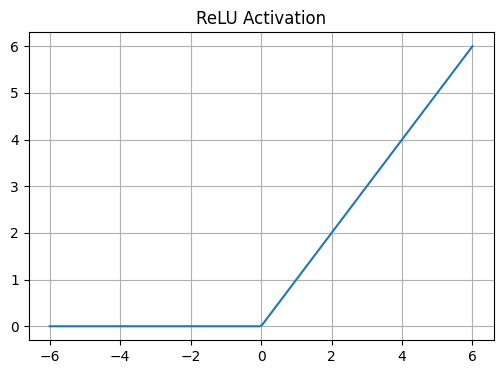

In [4]:
import matplotlib.pyplot as plt

x=np.linspace(-6,6,200)

plt.figure(figsize=(6,4))
plt.plot(x,1/(1+np.exp(-x)))
plt.title("Sigmoid Activation")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(x,np.maximum(0,x))
plt.title("ReLU Activation")
plt.grid(True)
plt.show()


# 7. Advantages

- Simple
- Fast
- Differentiable
- Foundation of deep learning
- Easy to optimize

# 8. Limitations

- Single neuron learns only linear decision boundaries
- Cannot solve XOR alone
- Requires stacking into multilayer networks
- Sensitive to activation choice


# 9. Historical Timeline

- 1943 — McCulloch-Pitts neuron
- 1958 — Perceptron (Rosenblatt)
- 1986 — Backpropagation popularized
- 2012 — Deep Learning breakthrough (AlexNet)


# 10. Landmark Papers

1. McCulloch & Pitts (1943) — *A Logical Calculus of the Ideas Immanent in Nervous Activity*
2. Frank Rosenblatt (1958) — *The Perceptron*
3. Rumelhart, Hinton & Williams (1986) — *Learning Representations by Back-propagating Errors*
4. Glorot et al. (2011) — *Deep Sparse Rectifier Neural Networks*


# 11. Exercises

1. Replace ReLU with GELU.
2. Implement LeakyReLU.
3. Add multiple neurons.
4. Build a two-layer MLP.
5. Compare Sigmoid vs ReLU.


In [7]:
import torch
import torch.nn as nn
class StandardNeuron(nn.Module):
    def __init__(self, in_features):
        super().__init__()

        self.linear = nn.Linear(in_features, 1)
        self.activation = nn.GELU()

    def forward(self, x):
        x = self.linear(x)
        x = self.activation(x)
        return x

model = StandardNeuron(4)
x = torch.randn(5,4)
print(model(x))

ModuleNotFoundError: No module named 'torch'

In [ ]:
import torch
import torch.nn as nn
class LeakyNeuron(nn.Module):
    def __init__(self,input_size):
        super().__init__()

        self.linear = nn.Linear(input_size,1)
        self.activation = nn.LeakyReLU(0.01)

    def forward(self,x):

        return self.activation(
            self.linear(x)
        )
model = LeakyNeuron(3)
x = torch.randn(10,3)

print(model(x))

In [ ]:
import torch
import torch.nn as nn

class MultiNeuronLayer(nn.Module):

    def __init__(self,input_size,neurons):

        super().__init__()

        self.layer = nn.Linear(input_size,neurons)
        self.activation = nn.ReLU()

    def forward(self,x):

        return self.activation(
            self.layer(x)
        )
model = MultiNeuronLayer(
            input_size=3,
            neurons=5
        )

x = torch.randn(8,3)

print(model(x))

In [ ]:
import torch
import torch.nn as nn

class TwoLayerMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(2,8),

            nn.ReLU(),

            nn.Linear(8,1),

            nn.Sigmoid()

        )

    def forward(self,x):

        return self.network(x)

model = TwoLayerMLP()

print(model)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-6,6,500)

sigmoid = 1/(1+np.exp(-x))

relu = np.maximum(0,x)

plt.figure(figsize=(8,5))

plt.plot(x,sigmoid,label="Sigmoid")

plt.plot(x,relu,label="ReLU")

plt.grid(True)

plt.legend()

plt.title("Sigmoid vs ReLU")

plt.show()

| Property           | Sigmoid                | ReLU              |
| ------------------ | ---------------------- | ----------------- |
| Formula            | ( \frac{1}{1+e^{-x}} ) | ( \max(0,x) )     |
| Output Range       | (0,1)                  | [0,∞)             |
| Differentiable     | Yes                    | Almost everywhere |
| Vanishing Gradient | High                   | Low               |
| Dead Neurons       | No                     | Yes               |
| Computational Cost | Higher                 | Very Low          |
| Hidden Layers      | Rare today             | Standard choice   |
| Output Layer       | Binary classification  | Rarely used       |


## Costum MLP from scratch

In [1]:
import torch
import torch.nn as nn

class CustomMLP(nn.Module):

    def __init__(self, input_size=4, hidden1=16, hidden2=8, output_size=1):
        super().__init__()

        # Layer 1 Parameters
        self.W1 = nn.Parameter(torch.randn(input_size, hidden1) * 0.02)
        self.b1 = nn.Parameter(torch.zeros(hidden1))

        # Layer 2 Parameters
        self.W2 = nn.Parameter(torch.randn(hidden1, hidden2) * 0.02)
        self.b2 = nn.Parameter(torch.zeros(hidden2))

        # Output Layer Parameters
        self.W3 = nn.Parameter(torch.randn(hidden2, output_size) * 0.02)
        self.b3 = nn.Parameter(torch.zeros(output_size))

        self.gelu = nn.GELU()

    def forward(self, x):

        # Layer 1
        x = torch.matmul(x, self.W1) + self.b1
        x = self.gelu(x)

        # Layer 2
        x = torch.matmul(x, self.W2) + self.b2
        x = self.gelu(x)

        # Output Layer
        x = torch.matmul(x, self.W3) + self.b3

        return x


model = CustomMLP()

print(model)

CustomMLP(
  (gelu): GELU(approximate='none')
)


In [ ]:
x = torch.randn(5,4)

output = model(x)

print(output)

In [ ]:
import torch.optim as optim

model = CustomMLP()

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

for epoch in range(500):

    x = torch.randn(32,4)

    y = torch.sum(x,dim=1,keepdim=True)

    prediction = model(x)

    loss = criterion(prediction,y)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

print(loss.item())

In [ ]:
# Parameter
for name, parameter in model.named_parameters():

    print(name)

    print(parameter.shape)

    print()